In [22]:
SIM_FILE = '/datascope/subaru/user/swei20/data/bosz50000/z1/mag205_225_lowT_1M/train_200k_0/dataset.h5'
TRAINING_FILE = '/datascope/subaru/user/swei20/blindspot_rv/inputs/bosz50000/b1_l9_e48_k25_s1_bn1_d1_T0_S0_L0_snr3_b50000_rv500_ep5000_N50000_m0.npz'
DENOISED_FILE = '/datascope/subaru/user/swei20/blindspot_rv/inputs/bosz50000_v3ep190/b1_l9_e48_k25_s1_bn1_d1_T0_S0_L0_snr3_b50000_rv500_ep5000_N50000_m0_v3ep190_N50000.npz'
DENOISED_MASK = '/datascope/subaru/user/swei20/model/bosz50000_mask.npy'

SMOOTHED_FILE = '/datascope/subaru/user/swei20/blindspot/results/downstream_smoother_outputs_2026-07-16/logg_downstream_smoother_outputs_savgol_e1_boxcar_w5_seed42_n5000_float32.npz'

N = 10000

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from collections import defaultdict
from tqdm.notebook import tqdm

from astropy.coordinates import SpectralCoord
import astropy.units as u
import specutils

In [24]:
plt.rcParams["text.usetex"] = True

# Load the training set

In [25]:
with np.load(TRAINING_FILE) as npz:
    training = {k: npz[k].copy() for k in npz.files}

list(training.keys())

['nl',
 'flux',
 'noisy',
 'wave',
 'flux_err',
 'rv',
 'teff',
 'logg',
 'mh',
 'snr0',
 'snr00']

In [26]:
training['wave'].shape, training['flux'].shape

((4096,), (50000, 4096))

In [32]:
wave = training['wave']

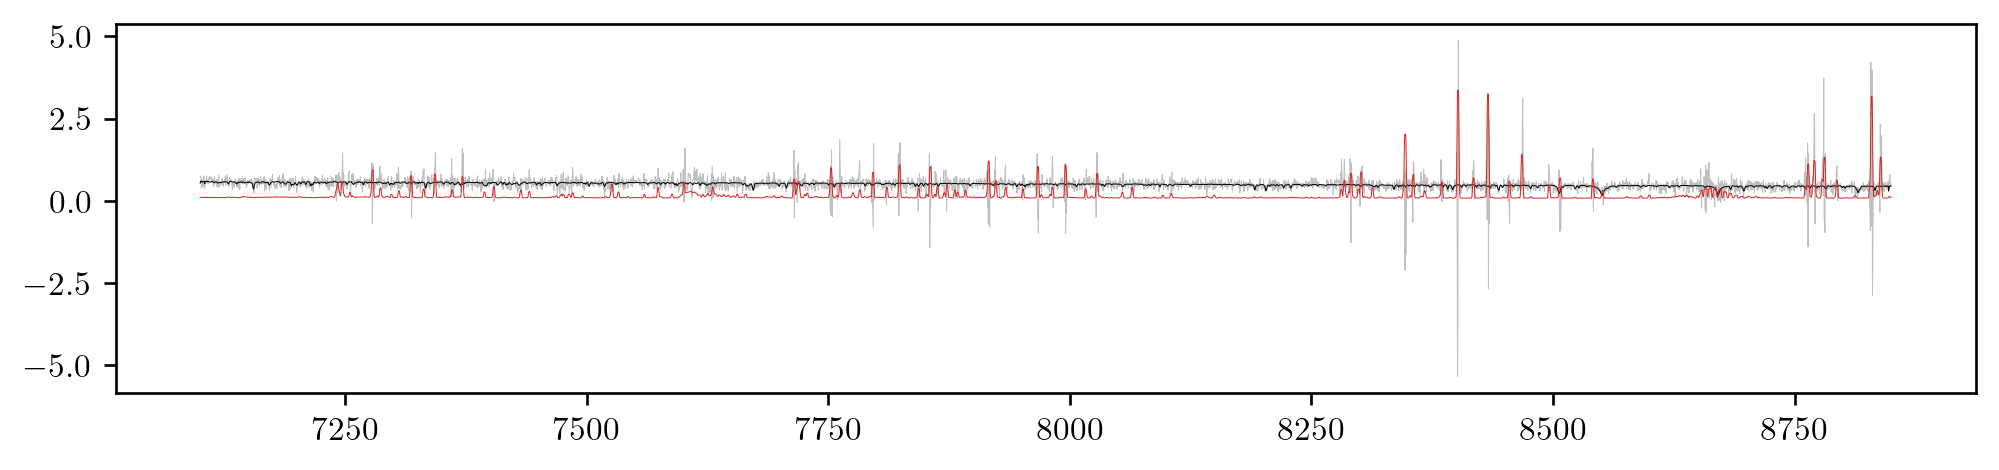

In [27]:
i = 0

w = training['wave']

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f = training['noisy'][i, :]
ax.plot(w, f, lw=0.3, c='gray', alpha=0.5)

f = training['flux'][i, :]
ax.plot(w, f, lw=0.3, c='k')

f = training['flux_err'][i, :]
ax.plot(w, f, lw=0.3, c='tab:red')

# Load the denoised data

In [28]:
wave_mask = np.load(DENOISED_MASK)
wave_mask.shape, wave_mask.sum()

((4096,), 3481)

In [29]:
denoised = np.load(DENOISED_FILE)
list(denoised.keys())

['wave',
 'flux',
 'noisy',
 'flux_err',
 'denoised',
 'rv',
 'teff',
 'logg',
 'mh',
 'snr0',
 'snr00',
 'snr_noisy_db',
 'snr_denoised_db',
 'nl',
 'ckpt',
 'config',
 'mask_path',
 'source_npz']

In [33]:
denoised['wave'].shape, denoised['flux'].shape

((3481,), (50000, 3481))

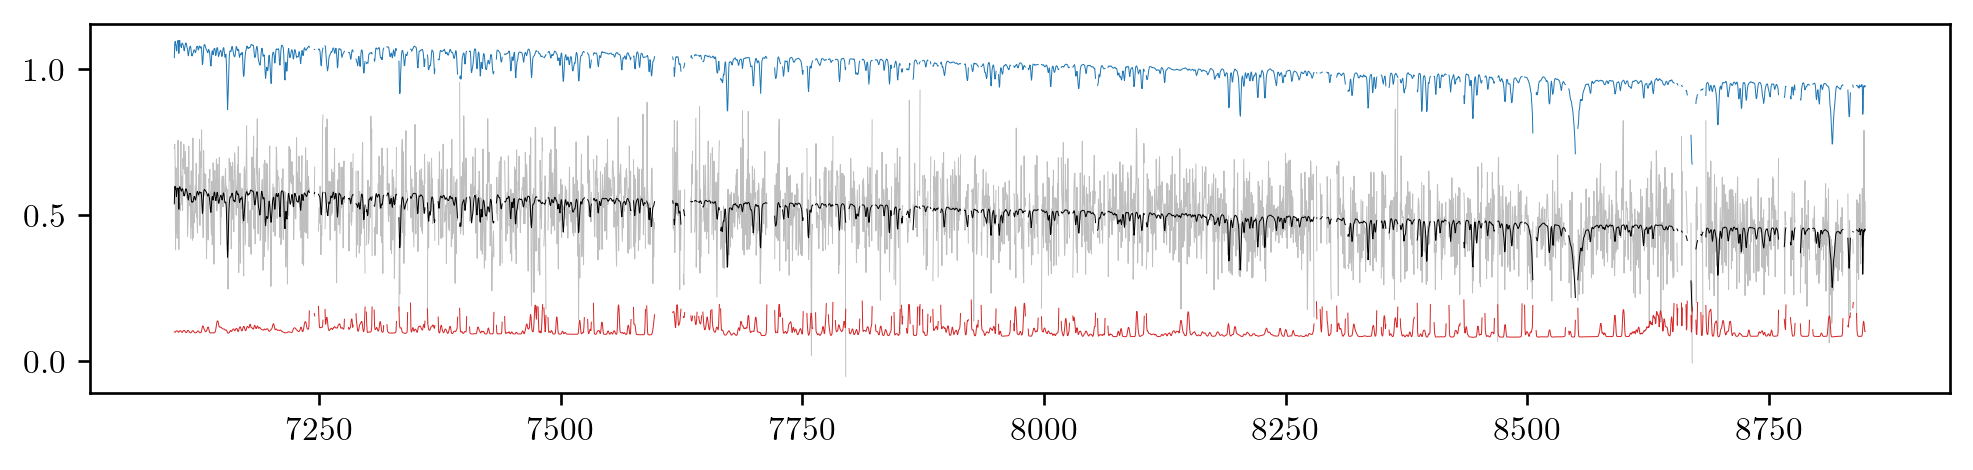

In [34]:
i = 0

w = wave
f = np.full_like(wave, np.nan)

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = denoised['noisy'][i, :]
ax.plot(wave, f, lw=0.3, c='gray', alpha=0.5)

f[wave_mask] = denoised['flux'][i, :]
ax.plot(wave, f, lw=0.3, c='k')

f[wave_mask] = denoised['denoised'][i, :]
ax.plot(wave, f + 0.5, lw=0.3, c='tab:blue')

f[wave_mask] = denoised['flux_err'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:red')

# Load smoothed spectra

In [35]:
with np.load(SMOOTHED_FILE) as npz:
    smoothed = {k: npz[k].copy() for k in npz.files}

list(smoothed.keys())

['wave', 'test_idx', 'savgol_e1', 'boxcar_w5']

In [36]:
smoothed['savgol_e1'].shape

(5000, 3481)

In [37]:
smoothed['boxcar_w5'].shape

(5000, 3481)

In [46]:
from scipy.signal import savgol_filter

smoothed_idx = 0, test_idx = 26365


(0.0, 1.2)

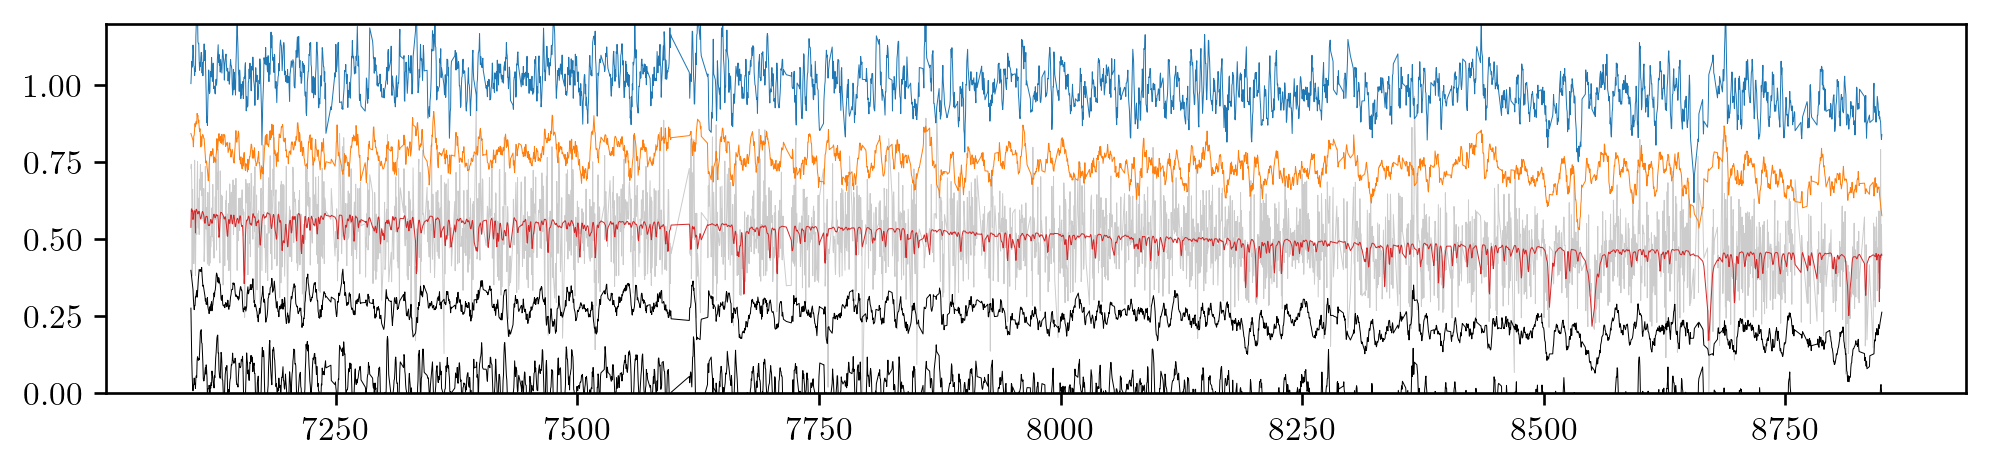

In [57]:
smoothed_idx = 0
test_idx = smoothed['test_idx']

print(f"smoothed_idx = {smoothed_idx}, test_idx = {test_idx[smoothed_idx]}")

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

# f = training['noisy'][i, :]
# ax.plot(training['wave'], f, lw=0.3, c='gray', alpha=0.3)

# f = training['flux'][i, :]
# ax.plot(training['wave'], f, lw=0.3, c='k')

f = denoised['noisy'][smoothed_idx, :]
ax.plot(denoised['wave'], f, lw=0.3, c='k', alpha=0.2)

ax.plot(denoised['wave'], savgol_filter(f, window_length=11, polyorder=1, axis=-1, mode="interp") - 0.25, lw=0.3, c='k')
ax.plot(denoised['wave'], savgol_filter(f, window_length=11, polyorder=3, axis=-1, mode="interp") - 0.5, lw=0.3, c='k')

f = denoised['flux'][smoothed_idx, :]
ax.plot(denoised['wave'], f, lw=0.3, c='tab:red')

f = smoothed['savgol_e1'][smoothed_idx, :]
ax.plot(smoothed['wave'], f + 0.25, lw=0.3, c='tab:orange')

f = smoothed['boxcar_w5'][smoothed_idx, :]
ax.plot(smoothed['wave'], f + 0.5, lw=0.3, c='tab:blue')

ax.set_ylim(0, 1.2)